# SCE Hosting Capacity Calculations

## Load packages & Data

In [27]:
import pandas as pd
import geopandas as gpd
import os
import matplotlib.pyplot as plt

os.environ['PROJ_LIB'] = '/opt/anaconda3/share/proj'

In [4]:
# Load data
zillow = gpd.read_parquet('~/../../capstone/electrigrid/data/zillow_complete_units.parquet').to_crs(epsg=3310)
sce = gpd.read_parquet("~/../../capstone/electrigrid/data/utilities/sce_circuits/ica_circuit_segments.parquet").to_crs(epsg=3310)
sce_cust = pd.read_csv("~/../../capstone/electrigrid/data/utilities/sce_circuits/ICA_Single_Consolidated_Table.csv")
sce_territory = gpd.read_file("~/../../capstone/electrigrid/data/utilities/sce_circuits/SCE_Service_Territory/SCE_Service_Territory.shp").to_crs(3310)
census = gpd.read_file("~/../../capstone/electrigrid/data/census/tl_2025_06_tract/tl_2025_06_tract.shp").to_crs(3310)

In [5]:
# Add residential percent & existing gen to circuits
sce = sce.merge(sce_cust[['circuit_name', 'res_pct', 'existing_gen']], how='left', on='circuit_name')

In [6]:
sce.columns

Index(['note', 'most_limiting_criteria_pv_of', 'circuit_name',
       'most_limiting_criteria_pv_sg', 'changed_date', 'ica_overall_pv',
       'most_limiting_criteria_ug_of', 'circuit_voltage', 'section_id',
       'uniform_generation_op_flex', 'substation_voltage', 'substation_name',
       'ica_overall_pv_op_flex', 'disclaimer', 'phase',
       'download_link_microgrid', 'uniform_generation',
       'most_limiting_criteria_lsg', 'system_name',
       'most_limiting_criteria_ug_sg', 'download_link', 'ica_overall_load',
       'lgp_flag', 'SHAPE__Length', 'objectid', 'node_id', 'geometry',
       'res_pct', 'existing_gen'],
      dtype='object')

## Clean data

In [8]:
# convert columns to numeric
# ica_overall_pv & uniform generation are already numeric
sce['ica_overall_load'] = pd.to_numeric(sce['ica_overall_load'], errors='coerce')
sce['ica_overall_pv_op_flex'] = pd.to_numeric(sce['ica_overall_pv_op_flex'], errors='coerce')
sce['uniform_generation_op_flex'] = pd.to_numeric(sce['uniform_generation_op_flex'], errors='coerce')

In [12]:
# some capacities are na, drop na rows based on columns
na_rows_count = len(sce) - len(sce.dropna(subset=['ica_overall_pv', 'ica_overall_load']))
print(f'Dropped rows: {na_rows_count}')

sce = sce.dropna(subset=['ica_overall_pv', 'ica_overall_load'])

Dropped rows: 25883


In [13]:
# crop zillow to only within sce territory
zillow_sce = gpd.sjoin(zillow, sce_territory[['geometry']], how='inner', predicate='within')[zillow.columns]

## Join buildings to closest segment

In [14]:
linked = gpd.sjoin_nearest(zillow_sce, sce, how='left', lsuffix='left', rsuffix='right', distance_col='dist_to_line_m')

In [15]:
# sum housing units per section_id 
units_per_seg = linked.groupby('section_id')['unit'].sum().rename('tothh_seg')
linked = linked.merge(units_per_seg, on='section_id')
# drop observations with no housing units, will avoid divide-by-zero error in per-household capacity calculation
linked = linked[linked['tothh_seg'] > 0]

# sum housing units across all segments in each circuit (tothh_ctot in Brockway Eq. 8)
units_per_circuit = linked.groupby('circuit_name')['unit'].sum().rename('tothh_circuit')
linked = linked.merge(units_per_circuit, on='circuit_name')

In [17]:
linked[['type', 'unit', 'GEOID', 'circuit_name', 'section_id', 'ica_overall_pv', 'tothh_seg', 'tothh_circuit']].head()

,type,unit,GEOID,circuit_name,section_id,ica_overall_pv,tothh_seg,tothh_circuit
0,Multi,1.0,06027000400,Underwood,42259964,0.0,10.0,2514.0
1,Multi,2.0,06027000200,Birchim,243103254,0.0,2.0,491.0
2,Multi,3.0,06027000300,Underwood,42260225,0.0,30.0,2514.0
3,Multi,3.0,06027000300,Underwood,42260225,0.0,30.0,2514.0
4,Multi,2.0,06027000200,Underwood,42260732,0.0,20.0,2514.0


## Calculate *DER_remain* function

In [18]:
def calc_der_remain(linked, cap_col):
    # drop any intermediate columns from previous iterations
    linked = linked.drop(columns=['DER_max_circuit', '_hhWt', 'summ_hhWt', '_hhWt_n', '_hhWt_nadj'], errors='ignore')
    
    # Part of Brockway Eq. 9: maximum capacity of the whole circuit
    max_cap = linked.groupby('circuit_name')[cap_col].max().rename('DER_max_circuit')
    linked = linked.merge(max_cap, on='circuit_name')

    # Brockway Eq. 8: find household-weighted capacity for each segment so that
    # segments serving more households contribute more to circuit total 
    linked['_hhWt'] = linked[cap_col] * (linked['tothh_seg'] / linked['tothh_circuit'])

    # Part of Brockway Eq. 9: sum of household-weighted capacities across all segments for each circuit
    # must deduplicate first as buildings sharing a segment would cause that segment's _hhWt to be counted multiple times
    summ_hhWt = linked.drop_duplicates('section_id').groupby('circuit_name')['_hhWt'].sum().rename('summ_hhWt')
    linked = linked.merge(summ_hhWt, on='circuit_name')
    
    # Brockway Eq. 9: normalize household-weighted capacity back to circuit maximum
    linked['_hhWt_n'] = linked['_hhWt'] * (linked['DER_max_circuit'] / linked['summ_hhWt'])

    # Brockway Eq. 10: cap normalized capacity at the segment's own capacty
    linked['_hhWt_nadj'] = linked[['_hhWt_n', cap_col]].min(axis=1)
    
    # Brockway Eq. 11: calculate DER_remain per household & convert to kW
    linked[f'DER_remain_{cap_col}'] = (linked['_hhWt_nadj'] / linked['tothh_seg']) * 1000

    return linked.drop(columns=['DER_max_circuit', '_hhWt', 'summ_hhWt', '_hhWt_n', '_hhWt_nadj'])

In [19]:
# call function
for col in ['ica_overall_pv', 'ica_overall_load']:
    linked = calc_der_remain(linked, col)

In [22]:
linked[['unit', 'section_id', 'tothh_seg', 'tothh_circuit', 'DER_remain_ica_overall_pv', 'DER_remain_ica_overall_load']]

,unit,section_id,tothh_seg,tothh_circuit,DER_remain_ica_overall_pv,DER_remain_ica_overall_load
0,1.0,42259964,10.0,2514.0,0.000000,0.105911
1,2.0,243103254,2.0,491.0,0.000000,0.254128
2,3.0,42260225,30.0,2514.0,0.000000,0.169457
3,3.0,42260225,30.0,2514.0,0.000000,0.169457
4,2.0,42260732,20.0,2514.0,0.000000,0.127093
...,...,...,...,...,...,...
3122166,1.0,23126785,4.0,1783.0,10.086859,1.741192
3122167,1.0,23125574,68.0,1783.0,5.043430,1.559159
3122168,1.0,23125574,68.0,1783.0,5.043430,1.559159
3122169,1.0,23125321,124.0,1783.0,18.492575,4.115546


# Add existing generation

In [23]:
linked['DER_exist_hh'] = (linked['existing_gen'] * 1000) / linked['tothh_circuit']

In [24]:
linked['DER_total_pv_hh'] = linked['DER_remain_ica_overall_pv'] + linked['DER_exist_hh']

In [25]:
linked[['unit', 'section_id', 'tothh_seg', 'tothh_circuit', 'DER_remain_ica_overall_pv', 'DER_remain_ica_overall_load', 'DER_total_pv_hh']]

,unit,section_id,tothh_seg,tothh_circuit,DER_remain_ica_overall_pv,DER_remain_ica_overall_load,DER_total_pv_hh
0,1.0,42259964,10.0,2514.0,0.000000,0.105911,0.810660
1,2.0,243103254,2.0,491.0,0.000000,0.254128,2.063136
2,3.0,42260225,30.0,2514.0,0.000000,0.169457,0.810660
3,3.0,42260225,30.0,2514.0,0.000000,0.169457,0.810660
4,2.0,42260732,20.0,2514.0,0.000000,0.127093,0.810660
...,...,...,...,...,...,...,...
3122166,1.0,23126785,4.0,1783.0,10.086859,1.741192,10.956741
3122167,1.0,23125574,68.0,1783.0,5.043430,1.559159,5.913312
3122168,1.0,23125574,68.0,1783.0,5.043430,1.559159,5.913312
3122169,1.0,23125321,124.0,1783.0,18.492575,4.115546,19.362457


In [ ]:
thresholds = [0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10]

total_hh = linked['unit'].sum()
summary = pd.DataFrame({
    'threshold': thresholds,
    'pv_prop_access': [linked.loc[linked['DER_total_pv_hh'] >= t, 'unit'].sum() / total_hh for t in thresholds],
    'load_prop_access': [linked.loc[linked['DER_remain_ica_overall_load'] >= t, 'unit'].sum() / total_hh for t in thresholds]
})

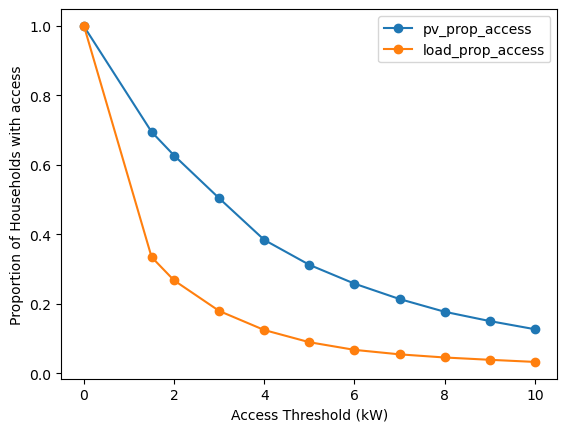

In [30]:
fig, ax = plt.subplots()
summary.plot(ax=ax, x='threshold', marker='o')
ax.set_xlabel('Access Threshold (kW)')
ax.set_ylabel('Proportion of Households with access')
plt.show()

## Add census tracts

In [ ]:
linked = linked.drop(labels=['index_right'], axis=1)

In [ ]:
# calculate households per census tract
tract_hh_count = linked.groupby(['GEOID', 'type'])['unit'].sum().reset_index(name='tract_hh_count')
tract_hh_count # FIXME: how to add into dataset? planning to use this with census variables

,GEOID,type,tract_hh_count
0,06019006408,Single,23.0
1,06019006409,Single,1664.0
2,06025012400,Single,172.0
3,06027000100,Multi,40.0
4,06027000100,Single,1296.0
...,...,...,...
5102,06111009500,Multi,33.0
5103,06111009500,Single,681.0
5104,06111009600,Single,1492.0
5105,06111009700,Multi,32.0


In [ ]:
# average der_remain to aggregate up to census tract level
# FIXME: need to implement weighted mean
census_der = linked.groupby('GEOID')[['DER_remain_ica_overall_pv', 'DER_remain_ica_overall_load', 'DER_total_pv_hh']].mean().reset_index() 
census_map = census.merge(census_der, on='GEOID')

In [ ]:
census_map.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,DER_remain_ica_overall_pv,DER_remain_ica_overall_load,DER_total_pv_hh
0,06,065,042516,06065042516,1400000US06065042516,425.16,Census Tract 425.16,G5020,S,973130,0,+33.9227363,-117.2393879,"POLYGON ((254831.161 -450428.536, 254879.224 -...",6.801336,3.173881,8.441692
1,06,065,042716,06065042716,1400000US06065042716,427.16,Census Tract 427.16,G5020,S,2698784,711913,+33.6865062,-117.2551285,"POLYGON ((252988.226 -477491.812, 253070.244 -...",0.000000,0.101470,4.162584
2,06,065,042717,06065042717,1400000US06065042717,427.17,Census Tract 427.17,G5020,S,6425166,145210,+33.6997108,-117.2534257,"POLYGON ((253204.987 -475305.031, 253228.177 -...",0.000000,0.350060,2.819148
3,06,065,042902,06065042902,1400000US06065042902,429.02,Census Tract 429.02,G5020,S,43393952,0,+33.7493422,-117.3068291,"POLYGON ((245709.226 -466855.471, 245710.230 -...",0.000000,3.450875,0.767381
4,06,065,042903,06065042903,1400000US06065042903,429.03,Census Tract 429.03,G5020,S,44642454,0,+33.8027798,-117.3133054,"POLYGON ((244083.685 -461694.249, 244084.463 -...",0.000000,0.246995,1.119654


In [ ]:
# census_map.to_parquet('census_map.parquet')

**Final Output:** Each census tract (within SCE area) and its respective DER remain capacities per household.